In [1]:
!pip install scikit-learn pandas numpy matplotlib seaborn scipy -q


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
SEED = 42
np.random.seed(SEED)
print("All libraries imported successfully.")

All libraries imported successfully.


In [3]:
df = pd.read_csv('mobile_banking_dataset.csv')
print(f"Total samples: {len(df)}")
print(df['Barrier_Label'].value_counts())
print(df.head(10))

Total samples: 200
Barrier_Label
Psychological    50
Technological    50
Social           50
Financial        50
Name: count, dtype: int64
   Perceived_Ease_of_Use  Internet_Access  Peer_Influence  Financial_Status  \
0                      3                3               4                 1   
1                      2                3               3                 3   
2                      2                2               4                 3   
3                      3                2               1                 4   
4                      3                3               4                 1   
5                      3                3               3                 2   
6                      3                2               2                 3   
7                      3                2               1                 3   
8                      2                5               1                 3   
9                      2                2               3              

In [6]:
FEATURES = ['Perceived_Ease_of_Use', 'Internet_Access', 'Peer_Influence',
            'Financial_Status', 'Prior_Experience', 'Privacy_Concern', 'Family_Norms']

In [7]:
le = LabelEncoder()
df['Label_Encoded'] = le.fit_transform(df['Barrier_Label'])
print("Label map:", dict(zip(le.classes_, le.transform(le.classes_))))

FEATURES = [col for col in df.columns if col not in ['Barrier_Label', 'Label_Encoded']]
X = df[FEATURES].values.astype(float)
y = df['Label_Encoded'].values

# Z-score outlier removal
z    = np.abs(stats.zscore(X))
mask = (z < 3).all(axis=1)
X, y = X[mask], y[mask]
print(f"Samples after outlier removal: {len(X)}")

# Min-Max normalisation
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Label map: {'Financial': np.int64(0), 'Psychological': np.int64(1), 'Social': np.int64(2), 'Technological': np.int64(3)}
Samples after outlier removal: 200
Train: 160 | Test: 40


In [8]:
baseline = DummyClassifier(strategy='most_frequent', random_state=SEED)
baseline.fit(X_train, y_train)
y_pred_base = baseline.predict(X_test)
print("Baseline trained.")

lr = LogisticRegression(solver='lbfgs', C=1.0, max_iter=1000, random_state=SEED)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Logistic Regression trained.")

svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=SEED)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print("SVM (RBF) trained.")

Baseline trained.
Logistic Regression trained.
SVM (RBF) trained.


In [9]:
def evaluate(y_true, y_pred, name):
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_true, y_pred) * 100, 2),
        'Precision': round(precision_score(y_true, y_pred, average='weighted', zero_division=0) * 100, 2),
        'Recall':    round(recall_score(y_true, y_pred,    average='weighted', zero_division=0) * 100, 2),
        'F1_Score':  round(f1_score(y_true, y_pred,        average='weighted', zero_division=0) * 100, 2),
    }

results_df = pd.DataFrame([
    evaluate(y_test, y_pred_base, 'Baseline'),
    evaluate(y_test, y_pred_lr,   'Logistic Regression'),
    evaluate(y_test, y_pred_svm,  'SVM (RBF)'),
]).set_index('Model')

print(results_df.to_string())
print("\n--- LR Report ---")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))
print("--- SVM Report ---")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

                     Accuracy  Precision  Recall  F1_Score
Model                                                     
Baseline                 25.0       6.25    25.0     10.00
Logistic Regression      82.5      82.95    82.5     82.23
SVM (RBF)                80.0      80.30    80.0     79.95

--- LR Report ---
               precision    recall  f1-score   support

    Financial       0.82      0.90      0.86        10
Psychological       0.75      0.60      0.67        10
       Social       1.00      0.90      0.95        10
Technological       0.75      0.90      0.82        10

     accuracy                           0.82        40
    macro avg       0.83      0.82      0.82        40
 weighted avg       0.83      0.82      0.82        40

--- SVM Report ---
               precision    recall  f1-score   support

    Financial       0.82      0.90      0.86        10
Psychological       0.67      0.60      0.63        10
       Social       1.00      0.90      0.95        10
Tec

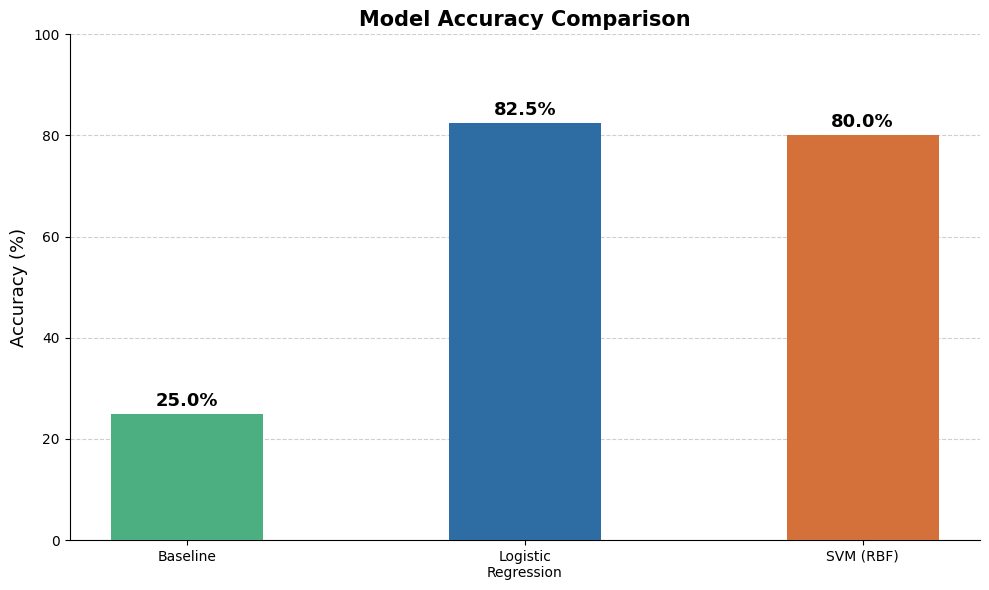

In [10]:
labels_cm = le.classes_
models    = ['Baseline', 'Logistic\nRegression', 'SVM (RBF)']
accs      = [results_df.loc[m, 'Accuracy'] for m in ['Baseline','Logistic Regression','SVM (RBF)']]
colors    = ['#4CAF82', '#2E6DA4', '#D4703A']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(models, accs, color=colors, width=0.45, zorder=3, edgecolor='none')
for bar, val in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')
ax.set_ylim(0, 100)
ax.set_ylabel('Accuracy (%)', fontsize=13)
ax.set_title('Model Accuracy Comparison', fontsize=15, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.grid(axis='x', visible=False)
plt.tight_layout()
plt.savefig('fig1_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

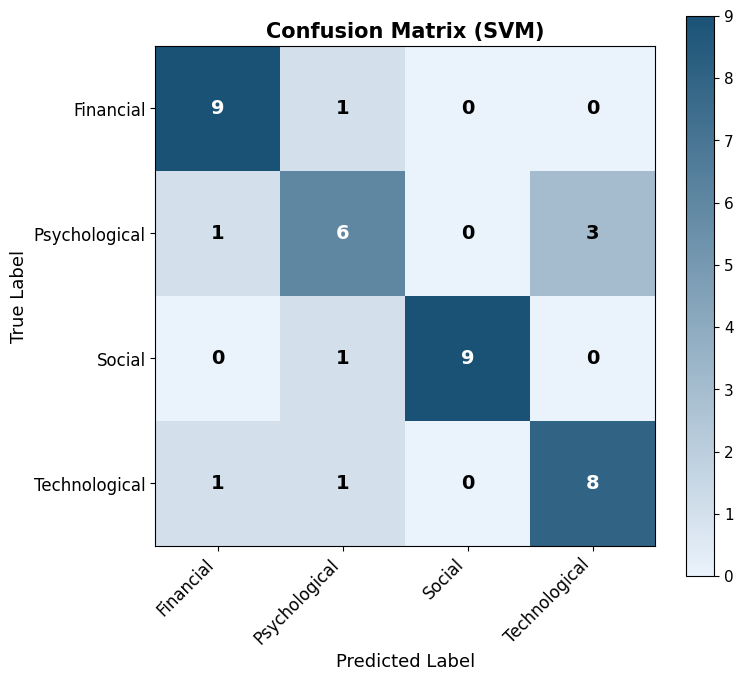

In [11]:
cm = confusion_matrix(y_test, y_pred_svm)
fig, ax = plt.subplots(figsize=(8, 7))
cmap = LinearSegmentedColormap.from_list('blue', ['#EAF2FB', '#1A5276'], N=256)
im = ax.imshow(cm, cmap=cmap, vmin=0, vmax=cm.max())
plt.colorbar(im, ax=ax).ax.tick_params(labelsize=11)
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels(labels_cm, rotation=45, ha='right', fontsize=12)
ax.set_yticklabels(labels_cm, fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=13)
ax.set_ylabel('True Label', fontsize=13)
ax.set_title('Confusion Matrix (SVM)', fontsize=15, fontweight='bold')
thresh = cm.max() / 2
for i in range(4):
    for j in range(4):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center', fontsize=14,
                fontweight='bold', color='white' if cm[i,j] > thresh else 'black')
plt.tight_layout()
plt.savefig('fig2_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

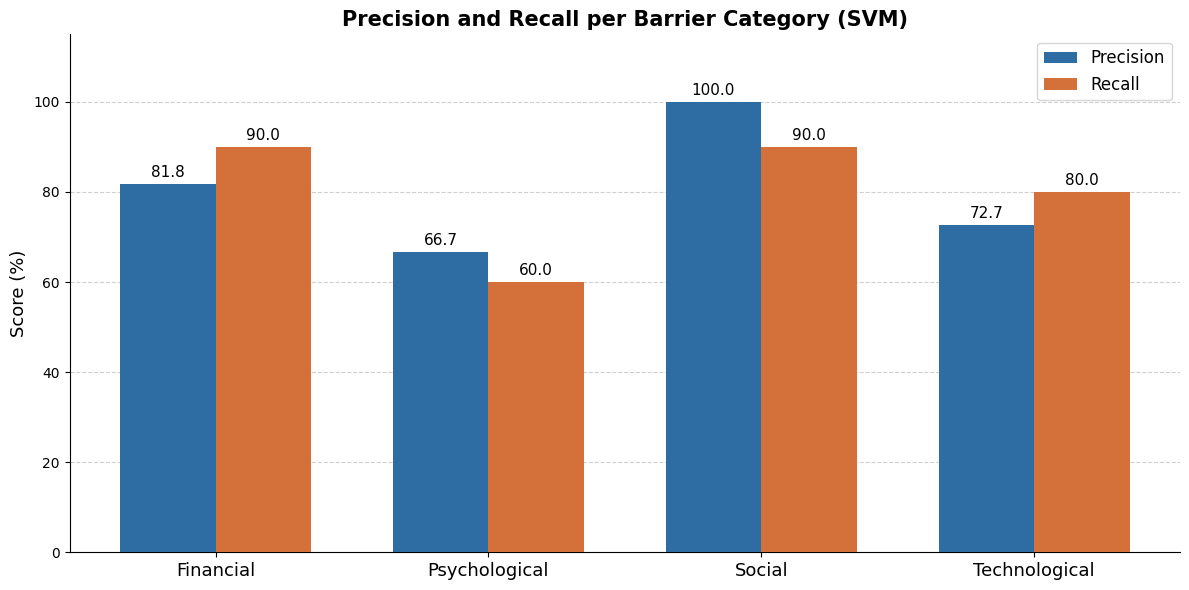

In [12]:
prec_per = precision_score(y_test, y_pred_svm, average=None, zero_division=0) * 100
rec_per  = recall_score(y_test, y_pred_svm,    average=None, zero_division=0) * 100
x, width = np.arange(4), 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bp = ax.bar(x - width/2, prec_per, width, color='#2E6DA4', label='Precision', zorder=3, edgecolor='none')
br = ax.bar(x + width/2, rec_per,  width, color='#D4703A', label='Recall',    zorder=3, edgecolor='none')
for bar, val in zip(bp, prec_per):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8, f'{val:.1f}', ha='center', va='bottom', fontsize=11)
for bar, val in zip(br, rec_per):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8, f'{val:.1f}', ha='center', va='bottom', fontsize=11)
ax.set_ylim(0, 115); ax.set_ylabel('Score (%)', fontsize=13)
ax.set_title('Precision and Recall per Barrier Category (SVM)', fontsize=15, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(labels_cm, fontsize=13)
ax.legend(fontsize=12)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.6); ax.grid(axis='x', visible=False)
plt.tight_layout()
plt.savefig('fig3_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()

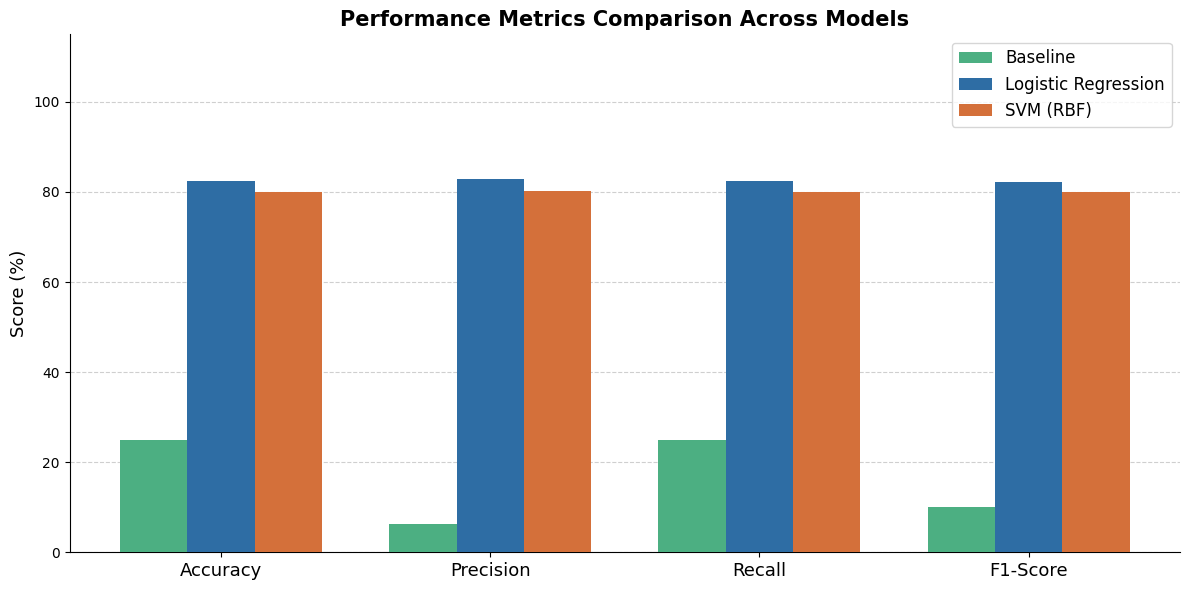

In [13]:
cols  = ['Accuracy','Precision','Recall','F1_Score']
names = ['Accuracy','Precision','Recall','F1-Score']
bv = [results_df.loc['Baseline',            c] for c in cols]
lv = [results_df.loc['Logistic Regression', c] for c in cols]
sv = [results_df.loc['SVM (RBF)',           c] for c in cols]
x, w = np.arange(4), 0.25

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x-w,   bv, w, color='#4CAF82', label='Baseline',            zorder=3, edgecolor='none')
ax.bar(x,     lv, w, color='#2E6DA4', label='Logistic Regression', zorder=3, edgecolor='none')
ax.bar(x+w,   sv, w, color='#D4703A', label='SVM (RBF)',           zorder=3, edgecolor='none')
ax.set_ylim(0, 115); ax.set_ylabel('Score (%)', fontsize=13)
ax.set_title('Performance Metrics Comparison Across Models', fontsize=15, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(names, fontsize=13)
ax.legend(fontsize=12, loc='upper right')
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.6); ax.grid(axis='x', visible=False)
plt.tight_layout()
plt.savefig('fig4_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

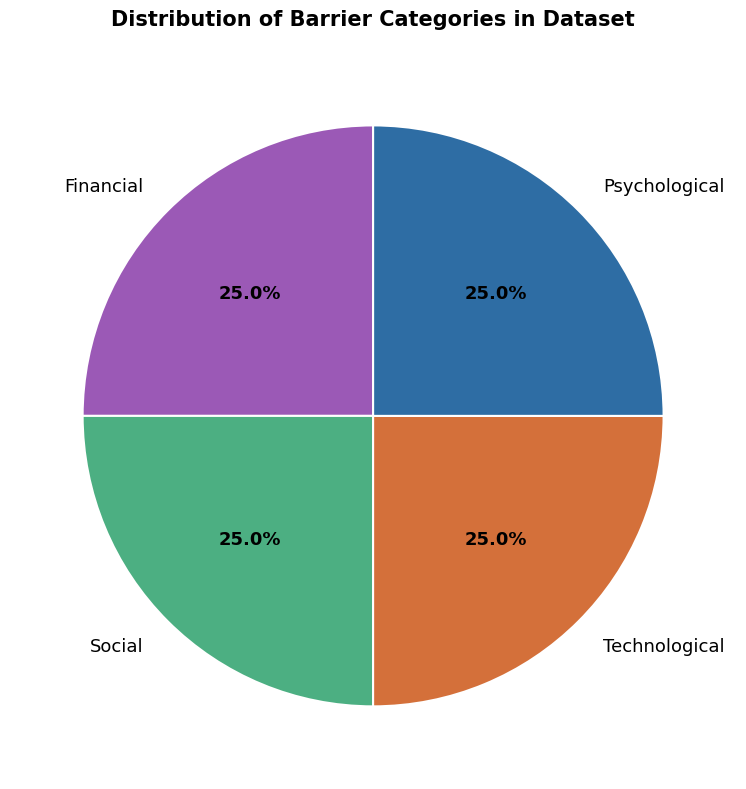

In [14]:
counts = df['Barrier_Label'].value_counts()
order  = ['Financial','Social','Technological','Psychological']
sizes  = [counts[l] for l in order]
colors_pie = ['#9B59B6','#4CAF82','#D4703A','#2E6DA4']

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    sizes, labels=order, colors=colors_pie, autopct='%1.1f%%',
    startangle=90, pctdistance=0.6, labeldistance=1.12,
    wedgeprops={'linewidth': 1.5, 'edgecolor': 'white'})
for t in texts:     t.set_fontsize(13)
for t in autotexts: t.set_fontsize(13); t.set_fontweight('bold')
ax.set_title('Distribution of Barrier Categories in Dataset', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('fig5_barrier_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
from google.colab import files
for f in ['mobile_banking_dataset.csv',
          'fig1_accuracy_comparison.png', 'fig2_confusion_matrix.png',
          'fig3_precision_recall.png',    'fig4_metrics_comparison.png',
          'fig5_barrier_distribution.png']:
    files.download(f)
    print(f"Downloaded: {f}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: mobile_banking_dataset.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: fig4_metrics_comparison.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: fig5_barrier_distribution.png
